# Regresión lineal por cuadrados mínimos

## Imports y funciones auxiliares

In [14]:
from scipy.stats.distributions import  t,chi2

from IPython.display import display, Math




def estimadores_ajuste(parametros,datos_x,datos_y,covarianza,alpha=0.05,print_rta=True):

    grado_del_polinomio = len(parametros)-1

    # Cantidad de parámetros
    P = grado_del_polinomio + 1

    # Número de datos
    N = len(datos_x)

    # Grados de libertad (Degrees Of Freedom)
    dof = N-P-1

    # Predicción del modelo para los datos_x medidos
    prediccion_modelo = np.polyval(parametros,datos_x)

    # Calculos de cantidades estadísticas relevantes
    COV       = covarianza                                # Matriz de Covarianza
    SE        = np.sqrt(np.diag( COV  ))                  # Standar Error / Error estandar de los parámetros
    residuos  = datos_y - prediccion_modelo               # diferencia enrte el modelo y los datos

    SSE       = np.sum(( residuos )**2 )                  # Resitual Sum of Squares
    SST       = np.sum(( datos_y - np.mean(datos_y))**2)  # Total Sum of Squares

    # http://en.wikipedia.org/wiki/Coefficient_of_determination
    # Expresa el porcentaje de la varianza que logra explicar el modelos propuesto
    Rsq       =  1 - SSE/SST                               # Coeficiente de determinación
    Rsq_adj   = 1-(1-Rsq) * (N-1)/(N-P-1)                  # Coeficiente de determinación Ajustado

    # https://en.wikipedia.org/wiki/Pearson_correlation_coefficient#In_least_squares_regression_analysis
    # Expresa la correlación que hay entre los datos y la predicción del modelo
    r_pearson = np.corrcoef( datos_y ,  prediccion_modelo )[0,1]

    # Reduced chi squared
    # https://en.wikipedia.org/wiki/Reduced_chi-squared_statistic
    chi2_red  = np.sum( residuos**2 )/(N-P)

    # Chi squared test
    chi2_test = np.sum( residuos**2 / np.abs(prediccion_modelo) )

    # p-value del ajuste
    p_val  = chi2(dof).cdf( chi2_test )

    sT = t.ppf(1.0 - alpha/2.0, N - P ) # student T multiplier
    CI = sT * SE

    rta = {'Rsq':Rsq,
           'Rsq_adj':Rsq_adj,
           'chi2_test':chi2_test,
           'r-pearson':r_pearson,
           'p-value':p_val}

    rta.update({'parametros':parametros,
                'COV':COV,
                'SE':SE,
                'CI':CI,
                'residuos':residuos})


    if print_rta:

        # Muestro la ecuacion
        ecuacion = r'\Large Y(x) \;=\; '
        for i,p in enumerate(parametros):
            orden = len(parametros)-i-1
            if orden>1:
                ecuacion += f' x^{ orden } \\cdot \\mathrm{{par}}[{i}] + '
            else:
              ecuacion += f' x \\cdot \\mathrm{{par}}[{i}] + ' if orden > 0 else f' \\mathrm{{par}}[{i}] '

        display(Math(ecuacion))
        print('\n')

        for key,val in rta.items():
            if key == 'parametros':
                print('\nParametros:')
                for jj,p in enumerate(val):
                    print(f'  parametro[{jj:3d}]: {p}')
            elif key == 'SE':
                print('\nError Estandar (SE):')
                for jj,p in enumerate(val):
                    print(f'  parametro[{jj:3d}]: {p}')
            elif key == 'CI':
                print('\nIntervalo de confianza al '+str((1-alpha)*100)+'%:')
                for jj,p in enumerate(val):
                    print(f'  parametro[{jj:3d}]: {p}')
            elif key == 'residuos' or key == 'COV':
                continue
            else:
                print(f'{key:20s}: {val}')

        print('')

        # print('R-squared    ',Rsq)
        # print('R-sq_adjusted',Rsq_adj)
        # print('chi2_test    ',chi2_test)
        # print('r-pearson    ',r_pearson)
        # print('p-value      ',p_val)
        # print('')
        # print('Error Estandar (SE):')
        # for i in range(P):
        #     print(f'parametro[{i:3d}]: ', parametros[i], ' ± ' , SE[i])
        # print('')
        # print('Intervalo de confianza al '+str((1-alpha)*100)+'%:')
        # for i in range(P):
        #     print(f'parametro[{i:3d}]: ', parametros[i], ' ± ' , CI[i])

    return rta



## Ajuste lineal simple

<IPython.core.display.Math object>



Rsq                 : 0.981211020970284
Rsq_adj             : 0.9777948429648811
chi2_test           : 0.2938372120933031
r-pearson           : 0.9905609627732578
p-value             : 8.049989336663859e-08

Parametros:
  parametro[  0]: 0.38083233527325894
  parametro[  1]: 2.1408751646721718

Error Estandar (SE):
  parametro[  0]: 0.015212954799595033
  parametro[  1]: 0.04717337027213488

Intervalo de confianza al 95.0%:
  parametro[  0]: 0.03314618109444733
  parametro[  1]: 0.10278194436739035



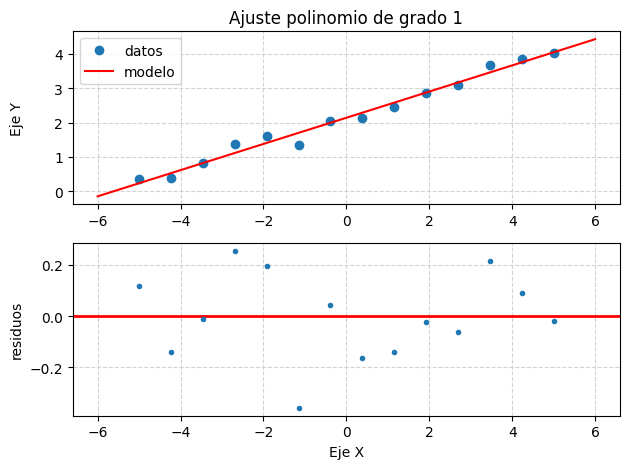

In [42]:
import numpy as np
import matplotlib.pyplot as plt


# Fabricamos algunos datos de ejemplo ################################
# Se establece una semilla para la reproducibilidad de los resultados aleatorios.
np.random.seed(0)

# Se generan 14 puntos de datos equiespaciados entre -5 y 5 para el eje x.
datos_x = np.linspace(-5,5,14)
# Se generan datos para el eje y con una relación lineal (0.4x + 2) y ruido aleatorio.
datos_y = 2 + datos_x * 0.4  + np.random.normal(size=len(datos_x))/5

# Esta sección debe ser reempalzada por la carga de los
# datos experimentales

######################################################################

# Se realiza un ajuste polinomial de grado 1 (lineal) a los datos_x y datos_y.
# np.polyfit devuelve los coeficientes del polinomio (parametros) y la matriz de covarianza.
parametros , covarianza  = np.polyfit( datos_x, datos_y, 1, cov=True)

# Fabricamos coordenadas del modelo
# Se generan puntos para el eje x que abarcan un rango más amplio para visualizar el modelo.
modelo_x    = np.linspace(-6,6)
# Se utilizan los parámetros del ajuste para calcular los valores y correspondientes al modelo.
modelo_y    = np.polyval( parametros , modelo_x )

# Se llama a la función auxiliar 'estimadores_ajuste' para calcular varias estadísticas del ajuste.
est_ajuste = estimadores_ajuste(parametros,datos_x,datos_y,covarianza)

# Se configura un gráfico con 2 subgráficos, apilados verticalmente.
plt.subplot(2,1,1)
# Se grafican los datos originales como puntos.
plt.plot( datos_x,  datos_y, 'o',              label='datos')
# Se grafica el modelo ajustado como una línea roja.
plt.plot(modelo_x, modelo_y, '-', color='red', label='modelo')

# Se muestra la leyenda para identificar los datos y el modelo.
plt.legend()
# Se agrega una cuadrícula.
plt.grid(True,linestyle='--',color='lightgray')
# plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.title('Ajuste polinomio de grado 1')
# Guardamos los limites del eje x para aplicarlos en el otro subplot
xlim=plt.gca().get_xlim()

# Se selecciona el segundo subgráfico.
plt.subplot(2,1,2)
# Se dibuja una línea horizontal en y=0 para los residuos.
plt.axhline( 0 , color='red', linewidth=2 )
# Se grafican los residuos (diferencia entre datos reales y predicción del modelo) como puntos.
plt.plot( datos_x,  est_ajuste['residuos'], '.',  label='residuos')
#plt.legend()
plt.grid(True,linestyle='--',color='lightgray')
plt.xlabel('Eje X')
plt.ylabel('residuos')
# Aplicamos los limites del eje x guardados
plt.xlim(xlim)

# Se alinea las etiquetas de los ejes Y de ambos subgráficos.
plt.gcf().align_ylabels()
# Se ajusta automáticamente los parámetros del subgráfico para un diseño ajustado.
plt.tight_layout()


### Version reducida sin comentarios



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

parametros , covarianza  = np.polyfit( datos_x, datos_y, 1, cov=True)
modelo_x    = np.linspace(-6,6)
modelo_y    = np.polyval( parametros , modelo_x )

est_ajuste = estimadores_ajuste(parametros,datos_x,datos_y,covarianza)

plt.subplot(2,1,1)
plt.plot( datos_x,  datos_y, 'o',              label='datos')
plt.plot(modelo_x, modelo_y, '-', color='red', label='modelo')
plt.legend()
plt.grid(True,linestyle='--',color='lightgray')
# plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.title('Ajuste polinomio de grado 1')
xlim=plt.gca().get_xlim()

plt.subplot(2,1,2)
plt.axhline( 0 , color='red', linewidth=2 )
plt.plot( datos_x,  est_ajuste['residuos'], '.',  label='residuos')

#plt.legend()
plt.grid(True,linestyle='--',color='lightgray')
plt.xlabel('Eje X')
plt.ylabel('residuos')
plt.xlim(xlim)

plt.gcf().align_ylabels()
plt.tight_layout()

## Ajuste lineal con errores en el eje Y




<IPython.core.display.Math object>



Rsq                 : 0.9203348945131298
Rsq_adj             : 0.9058503298791534
chi2_test           : 30.19613913819027
r-pearson           : 0.9688530803884695
p-value             : 0.9985240062110167

Parametros:
  parametro[  0]: 0.41115598732450037
  parametro[  1]: 2.12016386659549

Error Estandar (SE):
  parametro[  0]: 0.01694394373471716
  parametro[  1]: 0.05907813305975205

Intervalo de confianza al 95.0%:
  parametro[  0]: 0.03691768199429684
  parametro[  1]: 0.12872019426315026



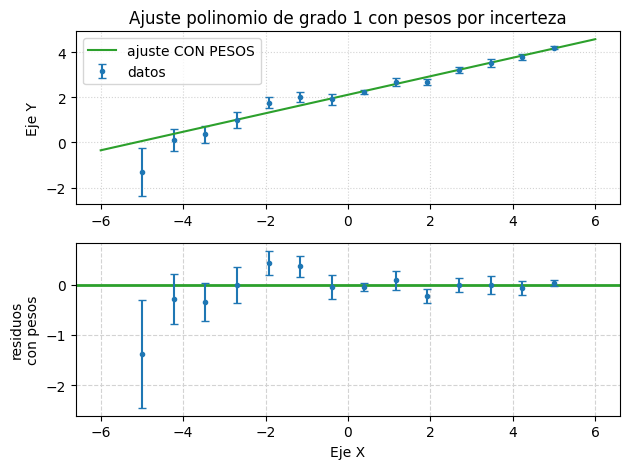

In [43]:
import numpy as np
import matplotlib.pyplot as plt


# Fabricamos algunos datos de ejemplo ##########################################
np.random.seed(1)

datos_x = np.linspace(-5,5,14)
datos_y = []
datos_y_err = []
for x in datos_x:
    y_tmp = np.random.normal(loc=2 + x * 0.4, size=10, scale=6*(1/(7+x))**1.2+np.random.uniform(0.1,0.3) )
    datos_y.append(np.mean(y_tmp))
    datos_y_err.append(np.std(y_tmp)/np.sqrt(10))

datos_y     = np.array(datos_y)
datos_y_err = np.array(datos_y_err)

# Estos datos simulan una medicion que consiste en medir 10 veces cada punto,
# promediar y luego asignar una incerteza de STD/sqrt(N)

# Esta sección debe ser reempalzada por la carga de los
# datos experimentales

################################################################################


MOSTRAR_TEORIA    = False
MOSTRAR_SIN_PESOS = False


# Ajuste lineal SIN pesos por incerteza ########################################
parametros , covarianza  = np.polyfit( datos_x, datos_y, 1, cov=True)

# Fabricamos coordenadas del modelo
modelo_x    = np.linspace(-6,6)
modelo_y    = np.polyval( parametros , modelo_x )

# est_ajuste = estimadores_ajuste(parametros,datos_x,datos_y,covarianza)
################################################################################



plt.subplot(2,1,1)
# plt.plot( datos_x,  datos_y, 'o',              label='datos')
plt.errorbar( datos_x, datos_y, yerr=datos_y_err,
            fmt='.',  capsize=3 , label='datos')

if MOSTRAR_TEORIA:
    plt.plot(modelo_x, modelo_x*0.4+2, '--', color='C3', alpha=0.8, label='teoría')

if MOSTRAR_SIN_PESOS:
    plt.plot(modelo_x, modelo_y, '-', color='C1', label='ajuste sin pesos')


# Ajuste lineal CON PESOS por incerteza ########################################
parametros , covarianza  = np.polyfit( datos_x, datos_y, 1, cov=True, w=1/datos_y_err )

# Cauculamos coordenadas del modelo
modelo_x    = np.linspace(-6,6)
modelo_y    = np.polyval( parametros , modelo_x )
plt.plot(modelo_x, modelo_y, '-', color='C2', label='ajuste CON PESOS')

est_ajuste = estimadores_ajuste(parametros,datos_x,datos_y,covarianza)


plt.legend()
plt.grid(True,linestyle=':',color='lightgray')
# plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.title('Ajuste polinomio de grado 1 con pesos por incerteza')
xlim=plt.gca().get_xlim()

plt.subplot(2,1,2)
plt.axhline( 0 , color='C2', linewidth=2 )
# plt.plot( datos_x,  est_ajuste['residuos'], '.',  label='residuos')
plt.errorbar( datos_x, est_ajuste['residuos'], yerr=datos_y_err,
            fmt='.',  capsize=3 , label='residuos')

#plt.legend()
plt.grid(True,linestyle='--',color='lightgray')
plt.xlabel('Eje X')
plt.ylabel('residuos\ncon pesos')
plt.xlim(xlim)

plt.gcf().align_ylabels()
plt.tight_layout()



## Ajuste polinómico


<IPython.core.display.Math object>



Rsq                 : 0.8640224422066689
Rsq_adj             : 0.8504246864273358
chi2_test           : 177.50287131821005
r-pearson           : 0.9295280749964837
p-value             : 1.0

Parametros:
  parametro[  0]: 0.06123020269321012
  parametro[  1]: -0.7074560733388348
  parametro[  2]: 0.7652346885243063
  parametro[  3]: 1.852943574710277

Error Estandar (SE):
  parametro[  0]: 0.004388261528508229
  parametro[  1]: 0.06164093726038034
  parametro[  2]: 0.20136176574737483
  parametro[  3]: 0.5186377019330237

Intervalo de confianza al 95.0%:
  parametro[  0]: 0.008862273945834062
  parametro[  1]: 0.12448639825374448
  parametro[  2]: 0.40665833580724237
  parametro[  3]: 1.0474100878693038



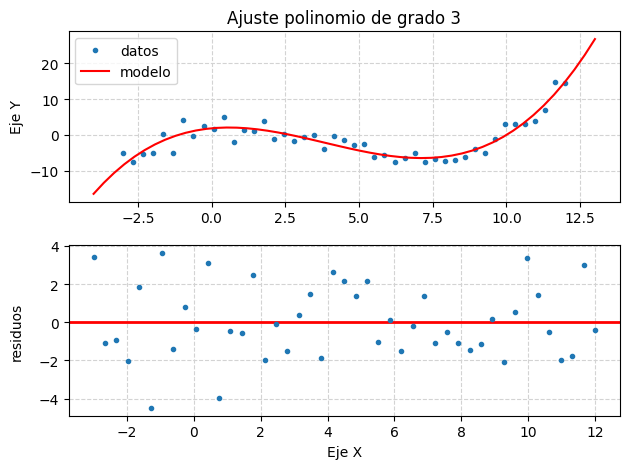

In [39]:
import numpy as np
import matplotlib.pyplot as plt


# Fabricamos algunos datos de ejemplo ################################
np.random.seed(1)

datos_x = np.linspace(-3,12,45)
datos_y = 2 +  0.8*datos_x - 0.7*datos_x**2 + 0.06*datos_x**3
datos_y += np.random.normal(size=len(datos_x))*2

# Esta sección debe ser reempalzada por la carga de los
# datos experimentales

######################################################################

parametros , covarianza  = np.polyfit( datos_x, datos_y, 3, cov=True)

# Fabricamos coordenadas del modelo
modelo_x    = np.linspace(-4,13)
modelo_y    = np.polyval( parametros , modelo_x )

est_ajuste = estimadores_ajuste(parametros,datos_x,datos_y,covarianza)

plt.subplot(2,1,1)
plt.plot( datos_x,  datos_y, '.',              label='datos')
plt.plot(modelo_x, modelo_y, '-', color='red', label='modelo')
plt.legend()
plt.grid(True,linestyle='--',color='lightgray')
# plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.title(f'Ajuste polinomio de grado {len(est_ajuste["parametros"])-1}')

plt.subplot(2,1,2)
plt.axhline( 0 , color='red', linewidth=2 )
plt.plot( datos_x,  est_ajuste['residuos'], '.',  label='residuos')

#plt.legend()
plt.grid(True,linestyle='--',color='lightgray')
plt.xlabel('Eje X')
plt.ylabel('residuos')

plt.gcf().align_ylabels()
plt.tight_layout()


## Ajuste lineal con presentación avanzada


<IPython.core.display.Math object>



Rsq                 : 0.902580737880751
Rsq_adj             : 0.8863441941942095
chi2_test           : 10.85782373712516
r-pearson           : 0.9500424926711178
p-value             : 0.45885901788273137

Parametros:
  parametro[  0]: 0.7982697673142882
  parametro[  1]: 1.9316431272950263

Error Estandar (SE):
  parametro[  0]: 0.0727373363204626
  parametro[  1]: 0.46958455616414024

Intervalo de confianza al 95.0%:
  parametro[  0]: 0.1571394615411906
  parametro[  1]: 1.0144757566951645



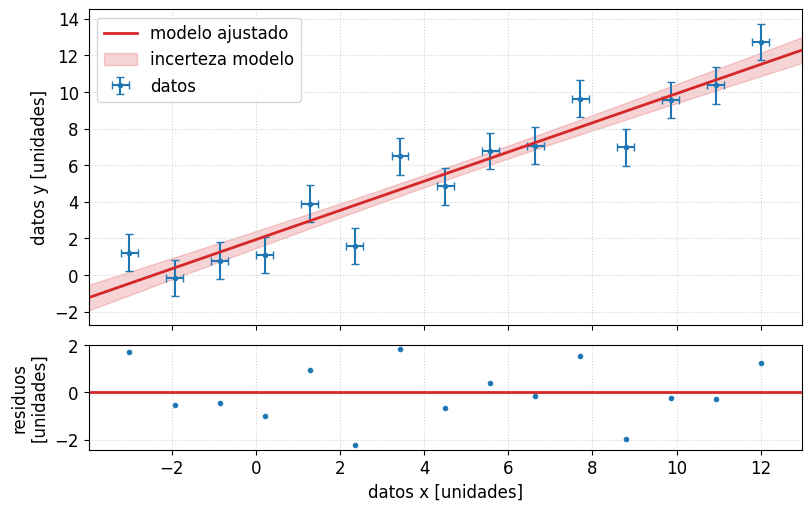

In [61]:
from numpy import *
import numpy as np
import matplotlib.pyplot as plt

# Fabricamos algunos datos de ejemplo ################################
np.random.seed(1)

datos_x = np.linspace(-3,12,15)
datos_y = 2 +  0.8*datos_x
datos_y += np.random.normal(size=len(datos_x))

# Esta sección debe ser reempalzada por la carga de los
# datos experimentales

######################################################################

# Graficamos los datos con sus errores
fig, (ax0,ax1) = plt.subplots(2, 1, figsize=(8,5), constrained_layout=True,
                              sharex=True, gridspec_kw={'height_ratios': [0.75,0.25]})


# Graficamos los datos medidos
ax0.errorbar( datos_x, datos_y, xerr=0.2, yerr=1,
            fmt='.', capsize=3 , label='datos')

# Guardo los límites actuales
lim = ax0.get_xlim()


parametros , covarianza  = np.polyfit( datos_x, datos_y, 1, cov=True)

# Fabricamos coordenadas del modelo
modelo_x    = np.linspace(-4,13)
modelo_y    = np.polyval( parametros , modelo_x )
est_ajuste  = estimadores_ajuste(parametros,datos_x,datos_y,covarianza)

A,B  = parametros
pcov = covarianza

# Calculamos valores que predice el modelo y sus incertezas
modelo_x     = linspace(lim[0],lim[1],300)
modelo_y     = A*modelo_x+B
# Ver:  https://stats.stackexchange.com/a/145220
modelo_y_err = sqrt( pcov[0,0] * modelo_x**2  + pcov[1,1] + 2*modelo_x*pcov[0,1] )



# Graficamos el ajuste
ax0.plot( modelo_x,  modelo_y, color='C3' , lw=2 , label='modelo ajustado')

# Graficamos la incerteza del ajuste
ax0.fill_between( modelo_x , modelo_y-modelo_y_err , modelo_y+modelo_y_err ,
                alpha=0.2 , color='C3' , label='incerteza modelo')
ax0.set_ylabel('datos y [unidades]')
ax0.legend()



ax1.axhline(0, color='C3' , lw=2 , label='modelo')
ax1.plot( datos_x,  est_ajuste['residuos'], '.' ,color='C0' , lw=2 , label='modelo ajustado')
ax1.set_ylabel('residuos\n[unidades]')
ax1.set_xlabel('datos x [unidades]')

for ax in (ax0,ax1):
    ax.grid(True, ls= ':', color='lightgray')
ax.set_xlim(lim)

plt.show()